# Ejercicio 4 - Comparacion de algoritmos de ordenamiento

Cuaderno para comparar `Ordenamiento por mezcla` e `Insercion` mediante pruebas de tiempo y graficas.


In [1]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt


In [2]:
def mezclar(izquierda, derecha):
    resultado = []
    indice_izquierda = 0
    indice_derecha = 0

    while indice_izquierda < len(izquierda) and indice_derecha < len(derecha):
        if izquierda[indice_izquierda] <= derecha[indice_derecha]:
            resultado.append(izquierda[indice_izquierda])
            indice_izquierda += 1
        else:
            resultado.append(derecha[indice_derecha])
            indice_derecha += 1

    resultado.extend(izquierda[indice_izquierda:])
    resultado.extend(derecha[indice_derecha:])
    return resultado


def ordenamiento_por_mezcla(arreglo):
    if len(arreglo) <= 1:
        return arreglo[:]

    medio = len(arreglo) // 2
    izquierda = ordenamiento_por_mezcla(arreglo[:medio])
    derecha = ordenamiento_por_mezcla(arreglo[medio:])
    return mezclar(izquierda, derecha)


def ordenamiento_por_insercion(arreglo):
    copia = arreglo[:]
    for indice in range(1, len(copia)):
        clave = copia[indice]
        posicion = indice - 1
        while posicion >= 0 and copia[posicion] > clave:
            copia[posicion + 1] = copia[posicion]
            posicion -= 1
        copia[posicion + 1] = clave
    return copia


## Verificacion con el arreglo base


In [3]:
arreglo_documento = [1, 6, 1, 7, 2, 3, 6, 6, 2, 6]

print("Arreglo original:", arreglo_documento)
print("Ordenamiento por mezcla:", ordenamiento_por_mezcla(arreglo_documento))
print("Ordenamiento por insercion:", ordenamiento_por_insercion(arreglo_documento))


Arreglo original: [1, 6, 1, 7, 2, 3, 6, 6, 2, 6]
Ordenamiento por mezcla: [1, 1, 2, 2, 3, 6, 6, 6, 6, 7]
Ordenamiento por insercion: [1, 1, 2, 2, 3, 6, 6, 6, 6, 7]


In [4]:
TAMANOS = [10, 50, 100, 500, 1000, 5000]
REPETICIONES = 20


def medir_tiempos(tamanos, repeticiones):
    tiempos_mezcla = []
    tiempos_insercion = []

    for tamano in tamanos:
        total_mezcla = 0.0
        total_insercion = 0.0

        for _ in range(repeticiones):
            arreglo = [random.randint(0, 10000) for _ in range(tamano)]

            inicio = time.perf_counter()
            ordenamiento_por_mezcla(arreglo)
            total_mezcla += time.perf_counter() - inicio

            inicio = time.perf_counter()
            ordenamiento_por_insercion(arreglo)
            total_insercion += time.perf_counter() - inicio

        tiempos_mezcla.append((total_mezcla / repeticiones) * 1000)
        tiempos_insercion.append((total_insercion / repeticiones) * 1000)

    return {
        "tamanos": tamanos,
        "tiempos_mezcla": tiempos_mezcla,
        "tiempos_insercion": tiempos_insercion,
    }


resultados = medir_tiempos(TAMANOS, REPETICIONES)

for tamano, mezcla, insercion in zip(resultados["tamanos"], resultados["tiempos_mezcla"], resultados["tiempos_insercion"]):
    print(f"n={tamano:4d} | Mezcla: {mezcla:.4f} ms | Insercion: {insercion:.4f} ms")


n=  10 | Mezcla: 0.0092 ms | Insercion: 0.0029 ms
n=  50 | Mezcla: 0.0862 ms | Insercion: 0.0605 ms
n= 100 | Mezcla: 0.1471 ms | Insercion: 0.2361 ms
n= 500 | Mezcla: 0.8299 ms | Insercion: 5.0354 ms
n=1000 | Mezcla: 1.9079 ms | Insercion: 21.9159 ms
n=5000 | Mezcla: 11.1499 ms | Insercion: 576.9294 ms


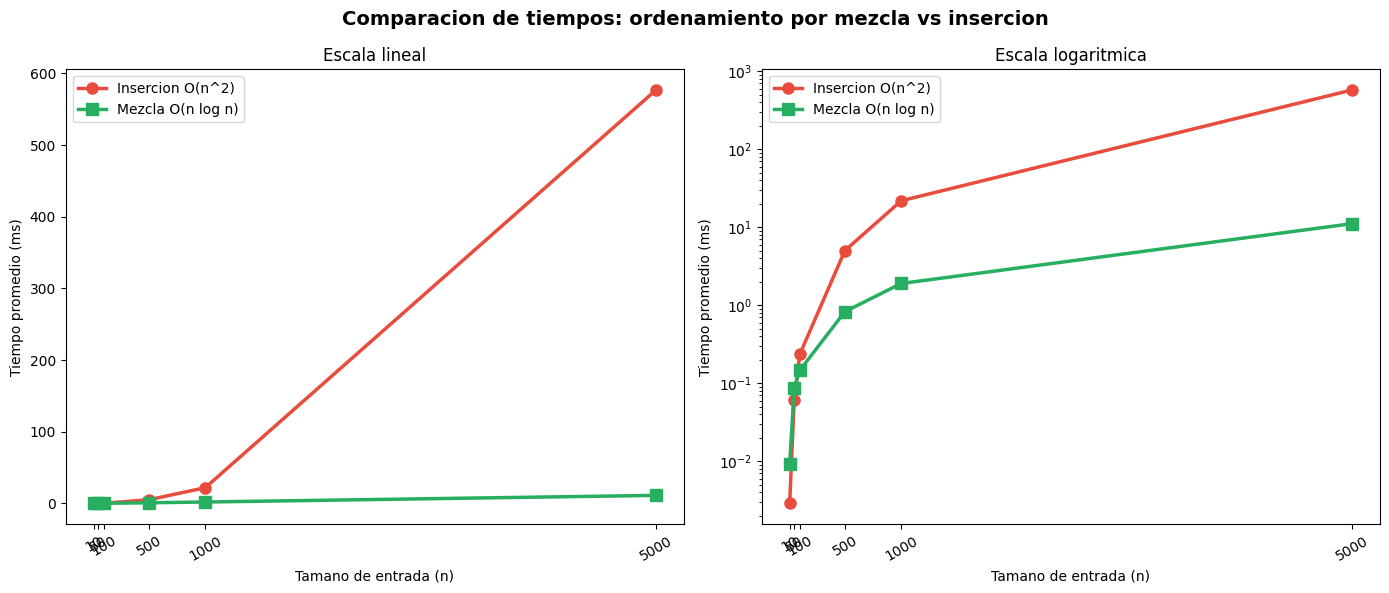

Grafica guardada en: /Users/darwin/Downloads/Momento Evaluativo 2/grafica_sorting.png


In [5]:
figura, (eje1, eje2) = plt.subplots(1, 2, figsize=(14, 6))

eje1.plot(resultados["tamanos"], resultados["tiempos_insercion"], marker="o", linewidth=2.5, markersize=8,
          color="#E74C3C", label="Insercion O(n^2)")
eje1.plot(resultados["tamanos"], resultados["tiempos_mezcla"], marker="s", linewidth=2.5, markersize=8,
          color="#27AE60", label="Mezcla O(n log n)")
eje1.set_title("Escala lineal")
eje1.set_xlabel("Tamano de entrada (n)")
eje1.set_ylabel("Tiempo promedio (ms)")
eje1.legend()
eje1.set_xticks(TAMANOS)
eje1.tick_params(axis="x", rotation=30)

eje2.plot(resultados["tamanos"], resultados["tiempos_insercion"], marker="o", linewidth=2.5, markersize=8,
          color="#E74C3C", label="Insercion O(n^2)")
eje2.plot(resultados["tamanos"], resultados["tiempos_mezcla"], marker="s", linewidth=2.5, markersize=8,
          color="#27AE60", label="Mezcla O(n log n)")
eje2.set_yscale("log")
eje2.set_title("Escala logaritmica")
eje2.set_xlabel("Tamano de entrada (n)")
eje2.set_ylabel("Tiempo promedio (ms)")
eje2.legend()
eje2.set_xticks(TAMANOS)
eje2.tick_params(axis="x", rotation=30)

figura.suptitle("Comparacion de tiempos: ordenamiento por mezcla vs insercion", fontsize=14, fontweight="bold")
plt.tight_layout()
ruta_salida = Path("grafica_sorting.png")
plt.savefig(ruta_salida, dpi=150, bbox_inches="tight")
plt.show()

print(f"Grafica guardada en: {ruta_salida.resolve()}")
